In [1]:
import numpy as np
import os
from os import PathLike
from pathlib import Path
from readimc import MCDFile, TXTFile
from collections import defaultdict
import pandas as pd
from typing import Any, Dict, Generator, List, Optional, Sequence, Tuple, Union
from tqdm.auto import tqdm

import os
import re
from readimc.data.acquisition import Acquisition, AcquisitionBase
from readimc.data.panorama import Panorama
from readimc.data.slide import Slide
import shutil
from scipy.ndimage import maximum_filter
import matplotlib.pyplot as plt
import tifffile
#import imcsegpipe
#from imcsegpipe.utils import sort_channels_by_mass
import  imcsegpipe._imcsegpipe as imcsegpipe
import warnings
def preprocess_image(img: np.ndarray, hpf: Optional[float] = None) -> np.ndarray:
    img = img.astype(np.float32)
    if hpf is not None:
        img = filter_hot_pixels(img, hpf)
    return img    
    return io._to_dtype(img, io.img_dtype)
def filter_hot_pixels(img: np.ndarray, thres: float) -> np.ndarray:
    kernel = np.ones((1, 3, 3), dtype=bool)
    kernel[0, 1, 1] = False
    max_neighbor_img = maximum_filter(img, footprint=kernel, mode="mirror")
    return np.where(img - max_neighbor_img > thres, max_neighbor_img, img)



In [28]:
tqdm.pandas()
path0 = '../IMC_data'
biobank = pd.read_excel(os.path.join(path0,'ExtraDocs','biobank list.xlsx'))
biobank.rename({'BIOBANK ID':'BIOBANK_ID'},inplace=True,axis = 1)
biobank.dropna(axis = 0,inplace=True)
biobank['code'] = biobank.BIOBANK_ID.str.split('-').str[0]
code_2_Leap = biobank[['LEAP ID','code']].drop_duplicates().set_index('code')

ome_tiff_paths = list(Path(path0+'/Leap009').rglob("acquisition/[!.]*.ome.tiff"))
path_tb = pd.DataFrame(ome_tiff_paths,columns = ['path'])
path_tb['filename'] = path_tb['path'].apply(lambda x:x.name).str.rstrip('_ac.ome.tiff')
path_tb['root'] = path_tb.path.astype(str).str.lstrip('../IMC_data/').str.split('/acquisition/').str[0]
new_names = []
metadata = pd.read_csv(path0+'/acquisition_metadata.csv')
metadata ['root'] = metadata.source_path.str.lstrip('/home/giuseppe/devices/Delta_Tissue/IMC/IMC_analysis../IMC_data').str.split('/').str[0]
metadata['description'] = metadata['description'].str.replace('170469269','17046926')#correct code for Leap54
panel_file = path_tb.iloc[0].path
panel_file = panel_file.with_name(panel_file.name[:-9]+'.csv')
panel = pd.read_csv(panel_file)
panel['marker'] = panel[panel.channel_label.str.contains('-')].channel_label.str.split('-',n = 1).str[1]
panel['marker'].loc[panel['channel_name'] == 'Pt195']='Carboplatin'
for _,file_row in tqdm(path_tb.iterrows()):
    #old_name = row['AcSession']+'_'+str(row['id'])
    # Pattern to match the specific format
    pattern = r"(.*)_s(\d)_a(\d{1,2})"
    
    # Find all occurrences of the pattern
    Leap_ID,_,acquisition_id = np.squeeze(re.findall(pattern, file_row.filename))
    row = metadata[(metadata.root==file_row.root)&(metadata.id==int(acquisition_id))&(metadata.AcSession == Leap_ID)]
    if len(row)>1:
        warnings.warn('Multiple matches')
    row = row.iloc[0]
    description = row.description.lstrip('ROI_')
    if any( x in description.upper() for x in ['LASER','TEST']):
        # this is a test file, ignore acquisition 
        continue

    if '_' in description:
        code = description.split('_')[1]
        if any([ el in description for el in ['Leap067', 'Leap068']]):
           code = description.split('_')[0]  
        
        if Leap_ID == 'Leap009_010_011':
            leap_9_10_11_mapper = {'19005858':'LEAP009','19005859':'LEAP011','19005860':'LEAP010'}#the sample id in the description is wrong
            Leap_ID = leap_9_10_11_mapper[code].capitalize()
        else:
            if re.match("^\d{8}$",code):
                #it is a 8 digits, looks like the code we want to use from biobank
                try:
                    Leap_ID = code_2_Leap.loc[code]['LEAP ID'].capitalize()
                except KeyError:
                    warning.warn('Potential problem, skipping')
                    pass
    if Leap_ID == 'Leap015_016':
        if 'TOP' in description:
            Leap_ID = 'Leap015'
        else:
            Leap_ID = 'Leap016'
    if Leap_ID == 'Leap017_018':
        if 'TOP' in description:
            Leap_ID = 'Leap017'
        else:
            Leap_ID = 'Leap018'
    if Leap_ID == 'Slide 42_MK_ROI':
        Leap_ID,row['id'] = description.split('_')
    new_name = Leap_ID+'_'+str(row['id'])
    new_names+=[new_name]
    
    img = tifffile.imread(file_row.path)
    if np.any(np.array(img.shape[1:])<128):
        #if image is not at least of 128 pixel per side, ignore it
        continue
    img= img[~panel.marker.isna()]
    output_path = '../combined_tiff/'+Leap_ID+'/'#
    if not os.path.exists(output_path):
        #if folder does not exist, create it
        os.makedirs(output_path)

    tifffile.imwrite( 
    output_path+new_name+'.tiff',
    data=img[np.newaxis, np.newaxis, :, :, :, np.newaxis],
    imagej=img.dtype in (np.uint8, np.uint16, np.float32),
    )
    #save in  the split_channels
    output_path_split = '../split_channels_nohpf/'+new_name+'/'# eg. ../split_channels/Leap001_10'               
    if not os.path.exists(output_path_split):
        #if folder does not exist, create it
        os.makedirs(output_path_split)
    for channel,marker in list(zip(img,panel.dropna(axis = 0).marker.values)):
        tifffile.imwrite( 
        output_path_split+marker+'.tiff',
        data=channel
        )



/tmp/ipykernel_8967/3920783576.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  panel['marker'].loc[panel['channel_name'] == 'Pt195']='Carboplatin'


0it [00:00, ?it/s]

In [26]:
ome_tiff_paths = list(Path(path0+'/Leap009').rglob("acquisition/[!.]*.ome.tiff"))


In [35]:
for _,file_row in tqdm(path_tb.iterrows()):
    #old_name = row['AcSession']+'_'+str(row['id'])
    # Pattern to match the specific format
    pattern = r"(.*)_s(\d)_a(\d{1,2})"
    
    # Find all occurrences of the pattern
    Leap_ID,_,acquisition_id = np.squeeze(re.findall(pattern, file_row.filename))
    code = description.split('_')[1]
    print(Leap_ID,code)
code_2_Leap.loc['19005858'].iloc[0].capitalize()

0it [00:00, ?it/s]

Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860
Leap009_010_011 19005860


'Leap001'

In [26]:
metadata[metadata.AcSession.str.contains('_')].AcSession.drop_duplicates()
path_tb[path_tb.filename.str.contains('Slide 42_MK_ROI')]

,path,filename,root
417,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a26,Leap103-105
418,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a21,Leap103-105
419,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a17,Leap103-105
420,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a1,Leap103-105
421,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a19,Leap103-105
422,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a29,Leap103-105
423,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a15,Leap103-105
424,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a18,Leap103-105
425,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a5,Leap103-105
426,../IMC_data/Leap103-105/acquisition/Slide 42_M...,Slide 42_MK_ROI_s0_a24,Leap103-105


In [23]:
metadata[metadata.AcSession=='Slide 42_MK_ROI']

,Unnamed: 0,AcSession,slide_id,origin,source_path,id,description,ablation_power,ablation_distance_between_shots_x,ablation_distance_between_shots_y,...,movement_type,segment_data_format,max_y,max_x,template,profiling_type,has_before_ablation_image,has_after_ablation_image,is_valid,root
971,0,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,1,Leap103_1,-3.0,1.0,1.0,...,XRaster,Float,925,986,KCL Nov 2023,Global,True,True,True,Leap103-105
972,1,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,2,Leap103_2,2.0,1.0,1.0,...,XRaster,Float,1126,955,KCL Nov 2023,Global,True,True,True,Leap103-105
973,2,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,3,Leap103_3,2.0,1.0,1.0,...,XRaster,Float,1728,1248,KCL Nov 2023,Global,True,True,True,Leap103-105
974,3,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,4,Leap103_4,2.0,1.0,1.0,...,XRaster,Float,1376,1121,KCL Nov 2023,Global,True,True,True,Leap103-105
975,4,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,5,Leap103_5,2.0,1.0,1.0,...,XRaster,Float,1184,1472,KCL Nov 2023,Global,True,True,True,Leap103-105
976,5,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,6,Leap103_6,2.0,1.0,1.0,...,XRaster,Float,1184,1280,KCL Nov 2023,Global,True,True,True,Leap103-105
977,6,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,7,Laser -5,-5.0,1.0,1.0,...,XRaster,Float,100,100,KCL Nov 2023,Global,True,True,False,Leap103-105
978,7,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,8,Laser -4,-4.0,1.0,1.0,...,XRaster,Float,100,100,KCL Nov 2023,Global,True,True,False,Leap103-105
979,8,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,9,Laser -3,-3.0,1.0,1.0,...,XRaster,Float,100,100,KCL Nov 2023,Global,True,True,False,Leap103-105
980,9,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,10,Laser -2,-2.0,1.0,1.0,...,XRaster,Float,100,100,KCL Nov 2023,Global,True,True,False,Leap103-105


In [77]:
a = 'Leap067_068'
any([ el in description for el in ['Leap067', 'Leap068']])

False

In [50]:
code_2_Leap.loc[code]['LEAP ID'].capitalize()
leap_9_10_11_mapper = {'19005858':'LEAP009','19005859':'LEAP010','19005860':'LEAP011'}#the sample id in the description is wrong
cond = merged.AcSession=='Leap009_010_011'

'Leap058'

In [39]:
if '_' in description:
    code = description.split('_')[1]
    if re.match("^\d{8}$",code):
        #it is a 8 digits, looks like the code we want to use from biobank
        print(code_2_Leap.loc[code]['LEAP ID'])
description

'ROI_002_17020143_x41523_y10928_w987_h1097'

In [66]:
path_tb[path_tb.filename.str.contains('88')]

,path,filename,root
204,../IMC_data/Leap088a/acquisition/Leap088a_s0_a...,Leap088a_s0_a6,Leap088a
205,../IMC_data/Leap088a/acquisition/Leap088a_s0_a...,Leap088a_s0_a9,Leap088a
206,../IMC_data/Leap088a/acquisition/Leap088a_s0_a...,Leap088a_s0_a5,Leap088a
207,../IMC_data/Leap088a/acquisition/Leap088a_s0_a...,Leap088a_s0_a7,Leap088a
208,../IMC_data/Leap088a/acquisition/Leap088a_s0_a...,Leap088a_s0_a3,Leap088a
209,../IMC_data/Leap088a/acquisition/Leap088a_s0_a...,Leap088a_s0_a2,Leap088a
210,../IMC_data/Leap088a/acquisition/Leap088a_s0_a...,Leap088a_s0_a4,Leap088a
211,../IMC_data/Leap088a/acquisition/Leap088a_s0_a...,Leap088a_s0_a8,Leap088a
212,../IMC_data/Leap088a/acquisition/Leap088a_s0_a...,Leap088a_s0_a1,Leap088a
669,../IMC_data/Leap088b/acquisition/Leap088b_s0_a...,Leap088b_s0_a5,Leap088b


In [20]:
panel[~panel.marker.isna()]

,channel_name,channel_label,marker
16,Pr141,141Pr-CD38,CD38
17,Nd142,142Nd-EGFR,EGFR
18,Nd143,143Nd-p53,p53
19,Nd144,144Nd-CD14,CD14
20,Nd145,145Nd-Tbet,Tbet
21,Nd146,146Nd-CD16,CD16
22,Sm147,147Sm-CD163,CD163
23,Nd148,148Nd-Pan-keratin,Pan-keratin
24,Sm149,149Sm-CD11b,CD11b
25,Nd150,150Nd-PD-L1,PD-L1


In [15]:
img = tifffile.imread(file_row.path)
img.shape
panel['marker'] = panel[panel.channel_label.str.contains('-')].channel_label.str.split('-',n = 1).str[1]
img[~panel.marker.isna()].shape

(37, 1030, 1009)

In [337]:
#metadata[(metadata.AcSession==Leap_ID)&(metadata.id==int(acquisition_id))]
Leap_ID
metadata.AcSession
a = pd.DataFrame(zip(path_tb.filename,new_names),columns = ['old','new'])
a#[a['new'].str.contains('088')]

,old,new
0,Leap064_s0_a1,Leap064_1
1,Leap064_s0_a2,Leap064_2
2,Leap064_s0_a5,Leap064_5
3,Leap064_s0_a4,Leap064_4
4,Leap064_s0_a3,Leap064_3
...,...,...
853,Leap020_s0_a2,Leap020_2
854,Leap020_s0_a3,Leap020_3
855,Leap020_s0_a1,Leap020_1
856,Leap020_s0_a5,Leap020_5


In [341]:
metadata['AcSession']+'_'+metadata['id'].astype(str)
871-858+21

34

In [155]:

metadata['AcSession']+'_'+metadata['id'].astype(str)
metadata

,Unnamed: 0,AcSession,slide_id,origin,source_path,id,description,ablation_power,ablation_distance_between_shots_x,ablation_distance_between_shots_y,...,roi_end_y_pos_um,movement_type,segment_data_format,max_y,max_x,template,profiling_type,has_before_ablation_image,has_after_ablation_image,is_valid
0,0,Leap001,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,8,ROI_001_19005858_x40459_y10966_w1084_h1058,6.0,1.0,1.0,...,9912.758,XRaster,Float,1058,1084,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True
1,1,Leap001,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,9,ROI_002_19005858_x40588_y11584_w961_h594,6.0,1.0,1.0,...,10987.099,XRaster,Float,594,961,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True
2,2,Leap001,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,10,ROI_003_19005858_x41026_y12042_w819_h464,6.0,1.0,1.0,...,11580.668,XRaster,Float,464,819,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True
3,0,Leap002,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,1,ROI_006_20001982_x27676_y12355_w1014_h975,6.5,1.0,1.0,...,11384.412,XRaster,Float,975,1014,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True
4,1,Leap002,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,2,ROI_001_20001982_x32573_y13792_w1031_h941 - no...,6.5,1.0,1.0,...,0.000,XRaster,Float,941,1031,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,24,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,25,Leap105_5,2.0,1.0,1.0,...,8831.798,XRaster,Float,1222,1176,KCL Nov 2023,Global,True,True,True
996,25,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,26,Leap105_6,2.0,1.0,1.0,...,9985.810,XRaster,Float,1222,1403,KCL Nov 2023,Global,True,True,True
997,26,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,27,Leap105_7,2.0,1.0,1.0,...,11139.971,XRaster,Float,1335,1154,KCL Nov 2023,Global,True,True,True
998,27,Slide 42_MK_ROI,0,mcd,/home/giuseppe/devices/Delta_Tissue/IMC/IMC_an...,28,Leap105_8,2.0,1.0,1.0,...,13252.008,XRaster,Float,1471,1199,KCL Nov 2023,Global,True,False,True


code below is to debug the extractions of mcd files


In [2]:
import numpy as np
import os
from os import PathLike
from pathlib import Path
from readimc import MCDFile, TXTFile
from collections import defaultdict
import pandas as pd
from typing import Any, Dict, Generator, List, Optional, Sequence, Tuple, Union
from tqdm import tqdm
from readimc.data.acquisition import Acquisition, AcquisitionBase
from readimc.data.panorama import Panorama
from readimc.data.slide import Slide
import shutil
from scipy.ndimage import maximum_filter
import tifffile
#import imcsegpipe
#from imcsegpipe.utils import sort_channels_by_mass
import  imcsegpipe._imcsegpipe as imcsegpipe

def preprocess_image(img: np.ndarray, hpf: Optional[float] = None) -> np.ndarray:
    img = img.astype(np.float32)
    if hpf is not None:
        img = filter_hot_pixels(img, hpf)
    return img    

def filter_hot_pixels(img: np.ndarray, thres: float) -> np.ndarray:
    kernel = np.ones((1, 3, 3), dtype=bool)
    kernel[0, 1, 1] = False
    max_neighbor_img = maximum_filter(img, footprint=kernel, mode="mirror")
    return np.where(img - max_neighbor_img > thres, max_neighbor_img, img)
def create_panel_from_acquisition(acquisition):
    '''Take as input the acquisition from the mcd file'''
    panel = pd.DataFrame(
                    data={
                        "channel": pd.Series(
                            data=acquisition.channel_names,
                            dtype=pd.StringDtype(),
                        ),
                        "name": pd.Series(
                            data=acquisition.channel_labels,
                            dtype=pd.StringDtype(),
                        ),
                    },
                )
    name = panel.name.str.split('-',n=1).str.get(1)
    panel['keep'] = ~name.isna()
    panel['name'] = name.where(panel.keep,'-')    
    panel.loc[panel['channel'] == 'Pt195', ['name', 'keep']] = ['Carboplatin', True]#add carboplatin to panel

    return panel

def save_tiff_from_mcd(mcd_file,Leap_folder):
    '''Save in ../combined_tiff and ../split_channels'''
    output_path = '../combined_tiff/'+Leap_folder+'/'#
    
    if not os.path.exists(output_path):
        #if /img folder does not exist, create it
        os.makedirs(output_path)

    with MCDFile(mcd_file) as f:
        for slide in f.slides:
            for acquisition in slide.acquisitions:
                if int(acquisition.metadata['DataEndOffset'])==0:
                    #corrupted acquisition
                    continue
                try:
                    img = f.read_acquisition(acquisition)
                except OSError:
                    continue # if mcd corrupt, move to next acquisition
                panel = create_panel_from_acquisition(acquisition)
                panel.to_csv(output_path.rstrip('/img')+'/panel.csv')
                img = img[panel.keep.values] #select only channels associated to antibody
                #img = preprocess_image(img,hpf=50)
                filename = Leap_folder+'_'+acquisition.metadata['ID']
                if np.any(np.array(img.shape[1:])<64):
                    #if image is not at least of 64 pixel per side, ignore it
                    continue
                tifffile.imwrite( 
                output_path+filename+'.tiff',
                data=img[np.newaxis, np.newaxis, :, :, :, np.newaxis],
                imagej=img.dtype in (np.uint8, np.uint16, np.float32),
                )
                #save in  the split_channels
                output_path_split = '../split_channels_nohpf/'+filename+'/'# eg. ../split_channels/Leap001_10'               
                if not os.path.exists(output_path_split):
                    #if folder does not exist, create it
                    os.makedirs(output_path_split)
                for channel,marker in list(zip(img,panel[panel.keep.values]['name'].values)):
                    tifffile.imwrite( 
                    output_path_split+marker+'.tiff',
                    data=channel
                    )


reprocess_mcd = True
path0 = '../IMC_data'
mcd_files_list = [str(el) for el in sorted(Path(path0).rglob("[!.]*.mcd"))]
mcd_files_list = [str(el) for el in sorted(Path(path0).rglob("[!.]*.mcd"))]
mcd_files_list = pd.Series(mcd_files_list)
mcd_files_list = mcd_files_list[~mcd_files_list.str.contains(r"Large Pano MCD files|PanoramasCRUCKCI")]# these are all empty without acquisitions


biobank = pd.read_excel(os.path.join(path0,'ExtraDocs','biobank list.xlsx'))
biobank.rename({'BIOBANK ID':'BIOBANK_ID'},inplace=True,axis = 1)
biobank.dropna(axis = 0,inplace=True)
biobank['code'] = biobank.BIOBANK_ID.str.split('-').str[0]
code_2_Leap = biobank[['LEAP ID','code']].drop_duplicates().set_index('code')

data_folder = ['/'.join(mcd_file.split('/')[:-1])for mcd_file in mcd_files_list]#take the path up to a level of the mcd file, it should contain the txt files

tiff_files = [str(el) for el in sorted(Path('../split_channels').rglob("[!.]*.tiff"))]
if reprocess_mcd:
    Leap_existing_files = []

else:
    Leap_existing_files =        pd.Series(tiff_files).str.lstrip('../split_channels').str.split('/').str[0].str.split('_').str[0].unique()

acquisition_metadatas = []
file_saved = []
for mcd_file,main_folder in tqdm(list(zip(mcd_files_list,data_folder))):
    #main_folder is where the mcd files sit
    Leap_folder = mcd_file.replace(path0,'.').split('/',maxsplit = 2)[1] 
    mcd_folder = '/'.join(mcd_file.split('/')[:-1])
    if mcd_file.lstrip(path0).split('/')[0] in Leap_existing_files:
        print('skipping'+mcd_file)
        continue
    #load metadata        
    try:
        acquisition_metadata = imcsegpipe.extract_mcd_file(mcd_file,acquisition_dir= mcd_folder)
        if any( x in acquisition.metadata['Description'].upper() for x in ['LASER','TEST']):
            # this is a test, ignore acquisition 
            continue
        description = acquisition_metadata.description.str.lstrip('ROI_')
        if '_' in description:
            code = description.split('_')[1]
            if re.match("^\d{8}$",code):
                #it is a 8 digits, looks like the code we want to use from biobank
                Leap_folder = code_2_Leap.loc[code]['LEAP ID']
        break
        #extract_mcd_file
        acquisition_metadatas.append(acquisition_metadata)
        save_tiff_from_mcd(mcd_file,Leap_folder)
        file_saved+=(list(Leap_folder +'_'+acquisition_metadata.id.astype(str).values))
    except OSError:
        continue
acquisition_metadata = pd.concat(acquisition_metadatas, copy=False)
acquisition_metadata.to_csv(path0 +"/acquisition_metadata.csv",mode = 'a')

  0%|                                                                                                                                                                                    | 0/123 [00:03<?, ?it/s]

KeyboardInterrupt



In [10]:
a = acquisition_metadata.description.str.lstrip('ROI_')
a.str.split('_').str[1]
mcd_files_list
main_folder

'../IMC_data/Leap004_2/raw'

In [3]:
path0 = '../IMC_data'
mcd_files_list = [str(el) for el in sorted(Path(path0).rglob("[!.]*.mcd"))]
mcd_files_list = [str(el) for el in sorted(Path(path0).rglob("[!.]*.mcd"))]
mcd_files_list = pd.Series(mcd_files_list)
mcd_files_list = mcd_files_list[~mcd_files_list.str.contains(r"Large Pano MCD files|PanoramasCRUCKCI")]# these are all empty without acquisitions

Leap_existing_files
mcd_files_list[~(mcd_files_list.str.lstrip(path0).str.split('/').str[0].isin(Leap_existing_files))]

24       ../IMC_data/Leap001/raw/Leap001.mcd
25       ../IMC_data/Leap002/raw/Leap002.mcd
26       ../IMC_data/Leap003/raw/Leap003.mcd
27     ../IMC_data/Leap004/raw/Leap004_1.mcd
28     ../IMC_data/Leap004_2/raw/Leap004.mcd
                       ...                  
142      ../IMC_data/Leap142-152/Leap148.mcd
143      ../IMC_data/Leap142-152/Leap149.mcd
144      ../IMC_data/Leap142-152/Leap150.mcd
145      ../IMC_data/Leap142-152/Leap151.mcd
146      ../IMC_data/Leap142-152/Leap152.mcd
Length: 123, dtype: object

In [6]:
data_folder = ['/'.join(mcd_file.split('/')[:-1])for mcd_file in mcd_files_list]
data_folder

['../IMC_data/Leap001/raw',
 '../IMC_data/Leap002/raw',
 '../IMC_data/Leap003/raw',
 '../IMC_data/Leap004/raw',
 '../IMC_data/Leap004_2/raw',
 '../IMC_data/Leap005/Leap005_1',
 '../IMC_data/Leap005/Leap005_2',
 '../IMC_data/Leap006',
 '../IMC_data/Leap008/raw',
 '../IMC_data/Leap009/raw',
 '../IMC_data/Leap010/raw',
 '../IMC_data/Leap011/raw',
 '../IMC_data/Leap012',
 '../IMC_data/Leap013/raw',
 '../IMC_data/Leap014/raw',
 '../IMC_data/Leap015/raw',
 '../IMC_data/Leap016/raw',
 '../IMC_data/Leap017',
 '../IMC_data/Leap018',
 '../IMC_data/Leap019',
 '../IMC_data/Leap020',
 '../IMC_data/Leap021',
 '../IMC_data/Leap022',
 '../IMC_data/Leap023',
 '../IMC_data/Leap024',
 '../IMC_data/Leap025/raw',
 '../IMC_data/Leap026',
 '../IMC_data/Leap028/raw',
 '../IMC_data/Leap029/raw',
 '../IMC_data/Leap030/raw',
 '../IMC_data/Leap031',
 '../IMC_data/Leap032/raw',
 '../IMC_data/Leap033/raw',
 '../IMC_data/Leap034',
 '../IMC_data/Leap035',
 '../IMC_data/Leap036',
 '../IMC_data/Leap037',
 '../IMC_data/

In [9]:
[mcd_file.replace(path0,'.').split('/',maxsplit = 2)[1]for mcd_file in mcd_files_list]

['Leap001',
 'Leap002',
 'Leap003',
 'Leap004',
 'Leap004_2',
 'Leap005',
 'Leap005',
 'Leap006',
 'Leap008',
 'Leap009',
 'Leap010',
 'Leap011',
 'Leap012',
 'Leap013',
 'Leap014',
 'Leap015',
 'Leap016',
 'Leap017',
 'Leap018',
 'Leap019',
 'Leap020',
 'Leap021',
 'Leap022',
 'Leap023',
 'Leap024',
 'Leap025',
 'Leap026',
 'Leap028',
 'Leap029',
 'Leap030',
 'Leap031',
 'Leap032',
 'Leap033',
 'Leap034',
 'Leap035',
 'Leap036',
 'Leap037',
 'Leap038',
 'Leap039',
 'Leap040',
 'Leap041',
 'Leap042',
 'Leap043',
 'Leap045',
 'Leap046',
 'Leap048',
 'Leap049',
 'Leap050',
 'Leap051',
 'Leap052',
 'Leap053',
 'Leap054',
 'Leap055',
 'Leap056',
 'Leap057',
 'Leap058',
 'Leap059',
 'Leap061',
 'Leap062',
 'Leap064',
 'Leap065',
 'Leap066',
 'Leap067',
 'Leap068',
 'Leap069',
 'Leap070',
 'Leap071',
 'Leap073',
 'Leap074',
 'Leap075',
 'Leap076',
 'Leap077',
 'Leap078',
 'Leap079',
 'Leap080',
 'Leap081',
 'Leap081',
 'Leap082',
 'Leap083',
 'Leap084',
 'Leap084',
 'Leap085',
 'Leap086',
 '

In [51]:
a = []
ids = []
with MCDFile('../IMC_data/Leap067/Leap067.mcd') as f:
    for slide in f.slides:
        for acquisition in slide.acquisitions:
            if int(acquisition.metadata['DataEndOffset'])==0:
                #corrupted acquisition
                continue
            try:
                img = f.read_acquisition(acquisition,strict = False)
                a+=[img]
                ids +=[acquisition.metadata['ID']]
            except OSError:
                continue # if mcd corrupt, move to next acquisition


/home/giuseppe/anaconda3/lib/python3.9/site-packages/readimc/mcd_parser.py:131: UserWarning: Slide 0 corrupted: overlapping memory blocks for acquisitions 1 and 2
  warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/readimc/mcd_file.py:169: UserWarning: MCD file 'Leap067.mcd' corrupted: inconsistent acquisition image data size
  warn(


In [66]:
slide.acquisitions[0].metadata

{'ID': '1',
 'Description': '17065269_Leap068_1_x10329_y15341_w1058_h960',
 'AblationPower': '5.5',
 'AblationDistanceBetweenShotsX': '1',
 'AblationDistanceBetweenShotsY': '1',
 'AblationFrequency': '200',
 'AcquisitionROIID': '1',
 'OrderNumber': '0',
 'SignalType': 'Dual',
 'DualCountStart': '1',
 'DataStartOffset': '57268681',
 'DataEndOffset': '321345481',
 'StartTimeStamp': '2023-05-30T17:16:03.0069599+01:00',
 'EndTimeStamp': '2023-05-30T18:56:54.2068986+01:00',
 'AfterAblationImageEndOffset': '2277953388',
 'AfterAblationImageStartOffset': '2277003064',
 'BeforeAblationImageEndOffset': '2277003064',
 'BeforeAblationImageStartOffset': '2275825021',
 'ROIStartXPosUm': '10329000',
 'ROIStartYPosUm': '15341000',
 'ROIEndXPosUm': '11387.497',
 'ROIEndYPosUm': '14385.263',
 'MovementType': 'XRaster',
 'SegmentDataFormat': 'Float',
 'ValueBytes': '4',
 'MaxY': '960',
 'MaxX': '1058',
 'PlumeStart': '0',
 'PlumeEnd': '0',
 'Template': 'c0154 Claudia Owczarek Breast Cancer Panel v1 1603

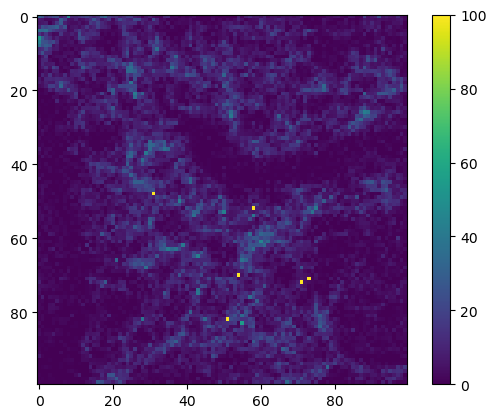

In [50]:
import skimage
#[acquisition.channel_labels=='141Pr-CD38']
plt.imshow(a[9][np.array(acquisition.channel_labels)=='141Pr-CD38'][0],vmax = 100)
plt.colorbar()

In [92]:
a = []
a+=(list(Leap_folder +'_'+acquisition_metadata.id.astype(str).values))
a+=(list(Leap_folder +'_'+acquisition_metadata.id.astype(str).values))

a

['Leap001_8',
 'Leap001_9',
 'Leap001_10',
 'Leap001_8',
 'Leap001_9',
 'Leap001_10']

In [12]:
mcd_files_list = [str(el) for el in sorted(Path(path0).rglob("[!.]*.mcd"))]
mcd_files_list = pd.Series(mcd_files_list)
mcd_files_list = mcd_files_list[~mcd_files_list.str.contains(r"Large Pano MCD files|PanoramasCRUCKCI")]# these are all empty without acquisitions

In [15]:

mcd_files_list

biobank = pd.read_excel(os.path.join(path0,'ExtraDocs','biobank list.xlsx'))
biobank.rename({'BIOBANK ID':'BIOBANK_ID'},inplace=True,axis = 1)
biobank.dropna(axis = 0,inplace=True)
biobank['code'] = biobank.BIOBANK_ID.str.split('-').str[0]

In [71]:
code_2_Leap = biobank[['LEAP ID','code']].drop_duplicates().set_index('code')
code_2_Leap.loc[code]['LEAP ID']

'LEAP001'

In [26]:
mcd_files_list.str.lstrip(path0).str.split('/').str[0]
os.path.join(path0,Leap_folder)

'../IMC_data/Leap004_2'

Exploring all acquisitions

In [34]:
a = pd.concat(acquisition_metadatas, copy=False)
a.AcSession.unique()

array(['S0685_COwczarek-Slide 2_22001707_panos only',
       'S0738_COwczarek-Slide9_17033996_17033161_BIG_PANOS',
       'S0739_COwczarek-Slide10_17032799_17033696_17034809_BIG PANOS',
       'S0740_COwczarek-Slide11_17034245_17035137_BIG_PANOS',
       'S0741_COwczarek-Slide12_170355507_17036104_BIGPANOS',
       'S0742_COwczarek-Slide13_17035505_17036102_BIG_PANOS',
       'S0743_COwczarek-Slide14_17035511_17036116_BIG_PANOS',
       'S0744_COwczarek-Slide15_17035379_17035253_BIG PANOS',
       'S0777_COwczarek-Slide 25_BIG PANOS',
       'S0778_COwczarek-Slide 26_BIG PANOS',
       'S0779_COwczarek-Slide 27_BIG PANOS',
       'S0785_COwczarek-Slide 17 PANOS', 'S0786_COwczarek-Slide 18 PANOS',
       'S0787_COwczarek-Slide 19 PANOS', 'S0788_COwczarek-Slide 20 PANOS',
       'S0789_COwczarek-Slide 21 PANOS', 'S0790_COwczarek-Slide 22 PANOS',
       'S0791_COwczarek-Slide 23 PANOS', 'S0792_COwczarek-Slide 28 PANOS',
       'S0793_COwczarek-Slide 29 PANOS', 'S0794_COwczarek-Slide 30 PA

In [27]:
with MCDFile('../IMC_data/Leap001/raw/Leap001.mcd') as f:
    imgs = []
    
    for slide in f.slides:
        img2 = f.read_slide(slide)
        
        for acquisition in slide.acquisitions:
                img  = f.read_acquisition(acquisition)
                imgs +=[img]
            
                #print('a problem with panorama',panorama.metadata)

In [29]:
acquisition.metadata

{'ID': '10',
 'Description': 'ROI_003_19005858_x41026_y12042_w819_h464',
 'AblationPower': '6',
 'AblationDistanceBetweenShotsX': '1',
 'AblationDistanceBetweenShotsY': '1',
 'AblationFrequency': '200',
 'AcquisitionROIID': '10',
 'OrderNumber': '0',
 'SignalType': 'Dual',
 'DualCountStart': '1',
 'DataStartOffset': '296244092',
 'DataEndOffset': '395048252',
 'StartTimeStamp': '2022-09-08T15:14:23.0813846+01:00',
 'EndTimeStamp': '2022-09-08T15:52:33.4387547+01:00',
 'AfterAblationImageEndOffset': '397093951',
 'AfterAblationImageStartOffset': '396741212',
 'BeforeAblationImageEndOffset': '396741212',
 'BeforeAblationImageStartOffset': '396272921',
 'ROIStartXPosUm': '41026000',
 'ROIStartYPosUm': '12042000',
 'ROIEndXPosUm': '41845.499',
 'ROIEndYPosUm': '11580.668',
 'MovementType': 'XRaster',
 'SegmentDataFormat': 'Float',
 'ValueBytes': '4',
 'MaxY': '464',
 'MaxX': '819',
 'PlumeStart': '0',
 'PlumeEnd': '0',
 'Template': 'c0154 Claudia Owczarek Breast Cancer Panel v1 16032022',


In [419]:
for acquisition in slide.acquisitions:
    print(acquisition.metadata['Description'])
    print(acquisition.slide.metadata)
acquisition.metadata['ID'],acquisition.metadata['Description']


('9', 'test_laser_power_55')

# Correcting old naming
Here creates a mapper of old names to new names.Also change the cell table fov

In [45]:
ac_metadata = pd.read_csv(os.path.join(path0,'acquisition_metadata.csv'),)
ac_metadata.drop_duplicates(inplace=True)
ac_metadata = ac_metadata[~(ac_metadata.AcSession=='AcSession')]#the csv file used to be appended oer and over, remove rows containing column headers
ac_metadata.source_path = ac_metadata.source_path.str.lstrip('/home/giuseppe/devices/Delta_Tissue/IMC/IMC_analysis')

In [106]:
ac_metadata[['AcSession','source_path']]
mapping  = pd.DataFrame()
old_leap_ID = ac_metadata.source_path.str.lstrip('/home/giuseppe/devices/Delta_Tissue/IMC/IMC_analysis/../IMC_data/').str.split('/').str[0]
mapping['old_name'] = old_leap_ID+ '_'+ac_metadata.id
mapping['remove'] = ac_metadata.description.str.contains('Laser')


In [47]:
ac_metadata.description

0       ROI_001_19005858_x40459_y10966_w1084_h1058
1         ROI_002_19005858_x40588_y11584_w961_h594
2         ROI_003_19005858_x41026_y12042_w819_h464
4         ROI_011_21002266_x24198_y15162_w848_h736
5        ROI_012_21002266_x24011_y13278_w1026_h775
                           ...                    
1003                                             7
1004                                             8
1005                                             9
1006                                            10
1007                                            11
Name: description, Length: 990, dtype: object

In [107]:

biobank = pd.read_excel(os.path.join(path0,'ExtraDocs','biobank list.xlsx'))
biobank.rename({'BIOBANK ID':'BIOBANK_ID'},inplace=True,axis = 1)
biobank.dropna(axis = 0,inplace=True)
biobank['code'] = biobank.BIOBANK_ID.str.split('-').str[0]
#biobank = biobank[~biobank.BIOBANK_ID.str.split('-',n=1).str[0].dropna().duplicated(keep = False)]#remove all repeated biobank_ID
ac_metadata['biobank_code'] = ac_metadata.description.str.lstrip('ROI_').str.split('_').str[1]

In [671]:
biobank[biobank.code.duplicated(keep = False)]

,LEAP ID,SLIDE NUMBER,BIOBANK_ID,SAMPLE TYPE (CORE/RESECTION),code
138,LEAP139,54.0,23002490-IncT FPE-5,RESECTION,23002490
151,LEAP152,60.0,23002490-IncT FPE-1,RESECTION,23002490


In [109]:
merged = ac_metadata.reset_index().merge(biobank,left_on='biobank_code',right_on='code',).set_index('index')
leap_9_10_11_mapper = {'19005858':'LEAP009','19005859':'LEAP010','19005860':'LEAP011'}#the sample id in the description is wrong
cond = merged.AcSession=='Leap009_010_011'
merged.loc[cond,'LEAP ID'] =merged.loc[cond].code.map(leap_9_10_11_mapper)
Leap_id = merged['LEAP ID'].str.lower().str.capitalize()+'_'+merged.id


In [110]:
mapping = mapping.merge(pd.DataFrame(Leap_id,columns = ['new_name']),left_index=True,right_index=True,how='left')

In [111]:
mapping[mapping.old_name!=mapping.new_name]

,old_name,remove,new_name
4,Leap004_2_11,False,Leap003_11
5,Leap004_2_12,False,Leap003_12
6,Leap004_2_13,False,Leap003_13
7,Leap004_2_14,False,Leap004_14
8,Leap004_2_15,False,Leap004_15
...,...,...,...
1003,Leap096_7,False,NaN
1004,Leap096_8,False,NaN
1005,Leap096_9,False,NaN
1006,Leap096_10,False,NaN


In [112]:
mapping.new_name = mapping.new_name.fillna(mapping.old_name)
mapping = mapping.drop_duplicates()
#mapping.to_csv('old_naming_to_new.csv')


In [131]:
mapping[mapping.old_name.str.split('_').str[0]!=mapping.new_name.str.split('_').str[0]].iloc[:50]


,old_name,remove,new_name
4,Leap004_2_11,False,Leap003_11
5,Leap004_2_12,False,Leap003_12
6,Leap004_2_13,False,Leap003_13
31,Leap003_14,False,Leap004_14
32,Leap003_15,False,Leap004_15
33,Leap003_16,False,Leap004_16
100,Leap009_1,False,Leap010_1
101,Leap009_2,False,Leap010_2
102,Leap009_3,False,Leap010_3
103,Leap009_4,False,Leap010_4


In [556]:
cell_table = pd.read_csv('../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv')

In [680]:
cond_cell_table = pd.merge(pd.DataFrame(cell_table.fov),mapping.drop_duplicates(),left_on = 'fov',right_on='old_name',how = 'inner')

In [755]:
imgintensities_protein = cell_table.iloc[:,1:cell_table.columns.get_loc('label')]
intensities_protein['Carboplatin'] = cell_table['Carboplatin_nuclear']


0          0.191300
1          0.179065
2          0.260888
3          0.172250
4          0.186000
             ...   
3964191    0.205868
3964192    0.194645
3964193    0.245185
3964194    0.245615
3964195    0.274401
Name: Carboplatin, Length: 3963619, dtype: float64

<Axes: >

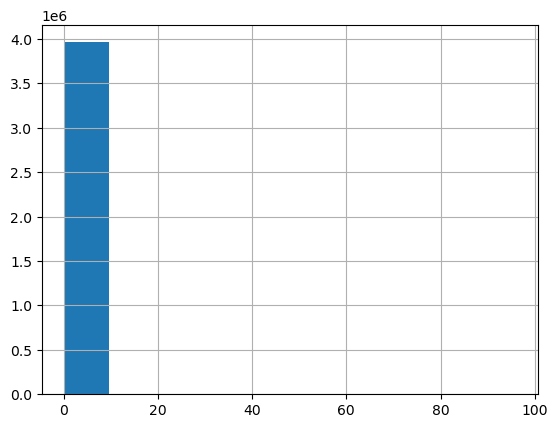

In [753]:
intensities_protein['Carboplatin'].hist()

In [690]:
cond_cell_table
cell_table['fov'] = cond_cell_table['new_name']
cell_table = cell_table[~cond_cell_table.remove]
cell_table.to_csv('../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv')

[]

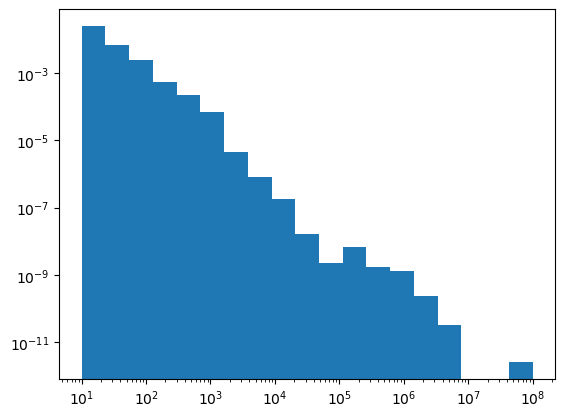

In [756]:
x = cell_table.loc[:,['Carboplatin_nuclear','Carboplatin']]
import matplotlib.pyplot as plt
import seaborn as sns
x.dropna(inplace = True)
#x = x[x<1]
#x.plot(x = 'Carboplatin_nuclear',y = 'Carboplatin',kind = 'scatter')
plt.hist(x.Carboplatin_nuclear,bins = np.logspace(1,8,20),density=True)
plt.loglog()

<Axes: xlabel='DNA1_nuclear', ylabel='DNA1'>

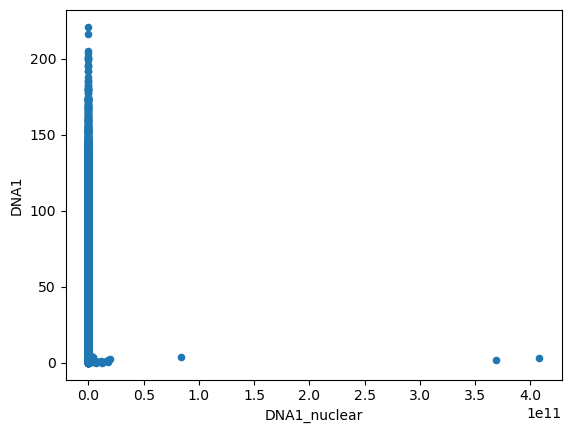

In [730]:
x = cell_table.loc[:,['DNA1_nuclear','DNA1']]
import matplotlib.pyplot as plt
x.dropna(inplace = True)
#x = x[x<1]
x.plot(x = 'DNA1_nuclear',y = 'DNA1',kind = 'scatter')

In [650]:

#ac_metadata[mapping[['old_name','new_name']].duplicated(keep = False)].iloc[:50]

,old_name,remove,new_name
0,Leap001_8,False,Leap001_8
1,Leap001_9,False,Leap001_9
2,Leap001_10,False,Leap001_10
4,Leap004_2_11,True,Leap003_11
5,Leap004_2_12,True,Leap003_12
...,...,...,...
1003,Leap096_7,False,Leap096_7
1004,Leap096_8,False,Leap096_8
1005,Leap096_9,False,Leap096_9
1006,Leap096_10,False,Leap096_10


In [391]:
cond = ac_metadata.AcSession!=old_leap_ID
sub = ac_metadata[cond].copy()
sub = sub[sub.AcSession.str.contains('Leap')& sub.AcSession.str.contains('_')]
cond =[np.all([len(x)==3 for x in el]) for el in sub.AcSession.str.lstrip('Leap_').str.split('_')]#check if all val
sub[np.array(cond)].head(20)

,Unnamed: 0,AcSession,slide_id,origin,source_path,id,description,ablation_power,ablation_distance_between_shots_x,ablation_distance_between_shots_y,...,movement_type,segment_data_format,max_y,max_x,template,profiling_type,has_before_ablation_image,has_after_ablation_image,is_valid,biobank_code
100,0.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,1,ROI_001_19005859_x18397_y10558_w744_h999,7.0,1.0,1.0,...,XRaster,Float,999,744,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005859
101,1.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,2,ROI_002_19005859_x18590_y11112_w543_h553,7.0,1.0,1.0,...,XRaster,Float,553,543,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005859
102,2.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,3,ROI_003_19005859_x18533_y11816_w543_h553,7.0,1.0,1.0,...,XRaster,Float,553,543,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005859
103,3.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,4,ROI_004_19005859_x18762_y14057_w501_h1042,7.0,1.0,1.0,...,XRaster,Float,1042,501,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005859
104,4.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,5,ROI_005_19005859_x18819_y12800_w472_h460,7.0,1.0,1.0,...,XRaster,Float,460,472,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005859
105,5.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,6,ROI_001_19005860_x33046_y16577_w329_h347,7.0,1.0,1.0,...,XRaster,Float,347,329,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005860
106,6.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,7,ROI_002_19005860_x32860_y15294_w329_h347,7.0,1.0,1.0,...,XRaster,Float,347,329,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005860
107,7.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,8,ROI_003_19005860_x32860_y15294_w329_h347,7.0,1.0,1.0,...,XRaster,Float,347,329,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005860
108,8.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,9,ROI_004_19005860_x32867_y14913_w329_h347,7.0,1.0,1.0,...,XRaster,Float,347,329,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005860
109,9.0,Leap009_010_011,0,mcd,../IMC_data/Leap009/raw/Leap009_010_011.mcd,10,ROI_005_19005860_x32895_y14532_w329_h347,7.0,1.0,1.0,...,XRaster,Float,347,329,c0154 Claudia Owczarek Breast Cancer Panel v1 ...,Global,True,True,True,19005860


In [369]:
sub.AcSession.str.lstrip('Leap_').str.split('_').drop_duplicates()

34            [004, 1]
63            [005, 2]
100    [009, 010, 011]
209         [015, 016]
227         [017, 018]
382         [034, 035]
530    [052, 053, 054]
569    [055, 056, 057]
629         [058, 059]
647         [061, 062]
710         [067, 068]
845           [084, b]
Name: AcSession, dtype: object

In [29]:
from skimage.io import imread
import skimage
import matplotlib.pyplot as plt
img = imread('../combined_tiff/Leap001/Leap001_10.tiff')
a = img[2]

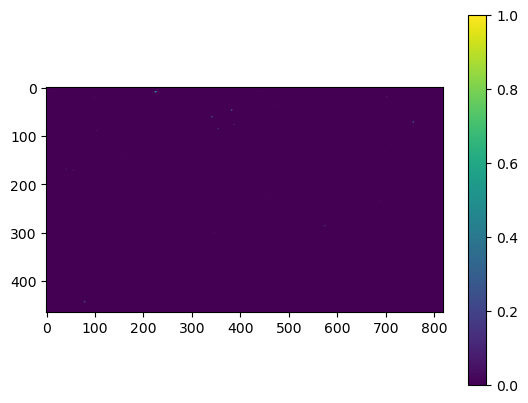

In [30]:
plt.imshow(skimage.exposure.rescale_intensity(a))
plt.colorbar()

[]

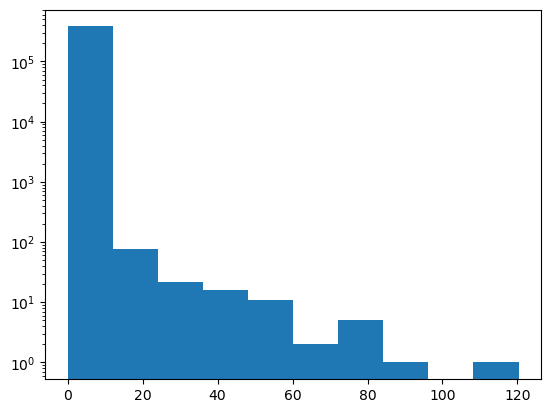

In [26]:
plt.hist(a.reshape(-1))
plt.semilogy()

In [37]:
a = panel.copy()
panel.loc[panel['channel'] == 'Pt195', ['name', 'keep']] = ['Carboplatin', True]
panel

,channel,name,keep
0,ArAr80,-,False
1,Y89,-,False
2,Zr90,-,False
3,Ru99,-,False
4,Rh103,-,False
...,...,...,...
57,Pt195,Carboplatin,True
58,Au197,-,False
59,Hg202,-,False
60,Pb207,-,False


In [6]:
import glob
import os
base_dir = '../IMC_data/'
sub_dir = 'img'
file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension

# Create a pattern to search for subdirectories with names starting with 'Leap'
sub_dir_pattern = os.path.join(base_dir, 'Leap*', sub_dir)

# Use glob to find all TIFF files in the subdirectories
tiff_files = glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True)
['/'.join(el.split('/')[:-1]) for el in tiff_files]

['../IMC_data/Leap015/img',
 '../IMC_data/Leap015/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap008/img',
 '../IMC_data/Leap032/img',
 '../IMC_data/Leap032/img',
 '../IMC_data/Leap032/img',
 '../IMC_data/Leap032/img',
 '../IMC_data/Leap030/img',
 '../IMC_data/Leap030/img',
 '../IMC_data/Leap030/img',
 '../IMC_data/Leap030/img',
 '../IMC_data/Leap033/img',
 '../IMC_data/Leap033/img',
 '../IMC_data/Leap033/img',
 '../IMC_data/Leap033/img',
 '../IMC_data/Leap033/img',
 '../IMC_data/Leap03

In [25]:
!ls ../IMC/processed/Leap001/
'/'.join(tiff_files[0].split('/')[:-1])

img  panel.csv


'../IMC/processed/Leap064/img'

In [100]:
tifffile.imwrite(
        '/home/giuseppe/Downloads/prova.tiff',
        data=img, #[np.newaxis, np.newaxis, :, :, :, np.newaxis],
        imagej=img.dtype in (np.uint8, np.uint16, np.float32),
    )
img.shape

(37, 464, 819)

In [32]:
a = tifffile.imread('../IMC_data/Leap001/raw/Leap001_s0_a10_ac.ome.tiff')
a.shape

(62, 464, 819)

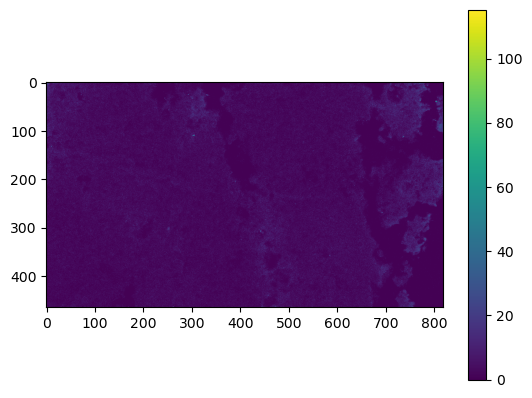

In [37]:
plt.imshow(a[10])
plt.colorbar()

In [35]:
b = tifffile.imread('../IMC/Leap001/data/Leap001_8.tiff')

FileNotFoundError: [Errno 2] No such file or directory: '/home/giuseppe/devices/Delta_Tissue/IMC/IMC/Leap001/data/Leap001_8.tiff'

In [124]:
np.all(a==b)

True

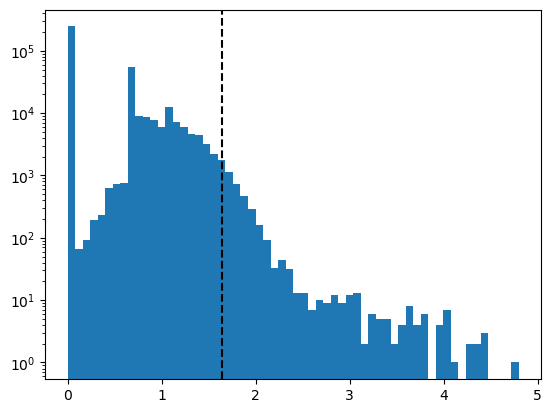

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
a= np.log1p(img[1].reshape(-1) )

plt.hist(a,60)
plt.semilogy()

plt.axvline(np.percentile(a,99.),ls = '--',c = 'k')

In [3]:
with MCDFile('../IMC_data/Leap001/raw/Leap001.mcd') as f:
        for slide in f.slides:
            for acquisition in slide.acquisitions:
                pass

In [4]:
acquisition.channel_labels

['80ArAr',
 '89Y',
 '90Zr',
 '99Ru',
 '103Rh',
 '106Pd',
 '107Ag',
 '112Cd',
 '114Cd',
 '115In',
 '120Sn',
 '127I',
 '131Xe',
 '138Ba',
 '139La',
 '140Ce',
 '141Pr-CD38',
 '142Nd-EGFR',
 '143Nd-p53',
 '144Nd-CD14',
 '145Nd-Tbet',
 '146Nd-CD16',
 '147Sm-CD163',
 '148Nd-Pan-keratin',
 '149Sm-CD11b',
 '150Nd-PD-L1',
 '151Eu-CD107a',
 '152Sm-CD45',
 '153Eu-CD44',
 '154Sm-CD366',
 '155Gd-FOXP3',
 '156Gd-CD4',
 '157Gd',
 '158Gd-E-Cadherin',
 '159Tb-CD68',
 '160Gd-HLA-DR-DQ-DP',
 '161Dy-CD20',
 '162Dy-CD8a',
 '163Dy-VEGF',
 '164Dy-PD-1',
 '165Ho-Beta-Catenin',
 '166Er-B7-H4',
 '167Er-Granzyme-B',
 '168Er-Ki-67',
 '169Tm-Collage-Type_I',
 '170Er-CD3',
 '171Yb-CD27',
 '172Yb-PD-L2',
 '173Yb-CD45RO',
 '174Yb-Alpha-SMA',
 '175Lu-Vimentin',
 '176Yb-CD31',
 '177Hf',
 '190BCKG',
 '191Ir-DNA1',
 '192Os',
 '193Ir-DNA2',
 '195Pt',
 '197Au',
 '202Hg',
 '207Pb',
 '209Bi']

In [19]:
slide.acquisitions[0].channel_labels
slide.acquisitions[0].

Slide(id=0, metadata={'ID': '0', 'Description': 'Slide', 'Filename': 'E:\\Files\\2022-Hyp\\2022-07\\2022-07-06-COwczarek-Breast Tumour Series\\S0686_COwczarek-Slide 3_19005864.mcd', 'SlideType': '""', 'WidthUm': '75000', 'HeightUm': '25000', 'ImageEndOffset': '27007', 'ImageStartOffset': '166', 'ImageFile': '""', 'EnergyDb': '9', 'Frequency': '200', 'FMarkSlideLength': '125000', 'FMarkSlideThickness': '12000', 'Name': 'Empty12AF', 'SwVersion': '7.0.8493.0'}, panoramas=[Panorama(slide=..., id=1, metadata={'ID': '1', 'SlideID': '0', 'Description': 's0686_20220708_154924.jpg_v7_x75000y25000.tif', 'SlideY4PosUm': '0.5', 'SlideX4PosUm': '0', 'SlideY3PosUm': '0.5', 'SlideX3PosUm': '75000', 'SlideY2PosUm': '24999.5', 'SlideX2PosUm': '75000', 'SlideY1PosUm': '24999.5', 'SlideX1PosUm': '0', 'ImageEndOffset': '4607614', 'ImageStartOffset': '27007', 'PixelWidth': '0', 'PixelHeight': '0', 'ImageFormat': 'PNG', 'PixelScaleCoef': '1', 'Type': 'Imported', 'IsLocked': 'true', 'RotationAngle': '0'}, ac

In [81]:
base_dir = '../IMC/processed/'
sub_dir = 'img'
file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension

# Create a pattern to search for subdirectories with names starting with 'Leap'
sub_dir_pattern = os.path.join(base_dir, 'Leap*', sub_dir)

# Use glob to find all TIFF files in the subdirectories
tiff_files = glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True)
panel_folders = ['/'.join(el.split('/')[:-2]) for el in tiff_files]# 2 levels up tiff files




# In[4]:
for tiff_file,panel_folder in zip(tiff_files,panel_folders):
    #assuming panel file is in Leap***/panel.csv
    panel = pd.read_csv(panel_folder+'/panel.csv',index_col=0)
    panel = panel[panel.keep==1]#select only the keep files
    #panel.name = panel.name.str.split('-',n=1).str.get(1)
    panel.reset_index(drop = True,inplace=True)
    img = imread(tiff_file)

    # In[5]:
    Leap_name = panel_folder.split('/')[-1]
    img_folder = '/'.join(tiff_file.split('/')[:-1]) # '../IMC/processed/Leap064/img'
    output_img_folder = img_folder+'/'+Leap_name
    if not os.path.exists(output_img_folder):
        #if /img folder does not exist, create it
        os.makedirs(output_img_folder)
    for channel,marker in list(zip(img,panel['name'].values)):
        '''
        tifffile.imwrite( output_img_folder+'/'+marker+'.tiff',
                    data=channel,
                    )
        '''
        print( output_img_folder+'/'+marker+'.tiff')

../IMC/processed/Leap064/img/Leap064/CD38.tiff
../IMC/processed/Leap064/img/Leap064/EGFR.tiff
../IMC/processed/Leap064/img/Leap064/p53.tiff
../IMC/processed/Leap064/img/Leap064/CD14.tiff
../IMC/processed/Leap064/img/Leap064/Tbet.tiff
../IMC/processed/Leap064/img/Leap064/CD16.tiff
../IMC/processed/Leap064/img/Leap064/CD163.tiff
../IMC/processed/Leap064/img/Leap064/Pan-keratin.tiff
../IMC/processed/Leap064/img/Leap064/CD11b.tiff
../IMC/processed/Leap064/img/Leap064/PD-L1.tiff
../IMC/processed/Leap064/img/Leap064/CD107a.tiff
../IMC/processed/Leap064/img/Leap064/CD45.tiff
../IMC/processed/Leap064/img/Leap064/CD44.tiff
../IMC/processed/Leap064/img/Leap064/CD366.tiff
../IMC/processed/Leap064/img/Leap064/FOXP3.tiff
../IMC/processed/Leap064/img/Leap064/CD4.tiff
../IMC/processed/Leap064/img/Leap064/E-Cadherin.tiff
../IMC/processed/Leap064/img/Leap064/CD68.tiff
../IMC/processed/Leap064/img/Leap064/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap064/img/Leap064/CD20.tiff
../IMC/processed/Leap064/img/Leap0

../IMC/processed/Leap064/img/Leap064/CD38.tiff
../IMC/processed/Leap064/img/Leap064/EGFR.tiff
../IMC/processed/Leap064/img/Leap064/p53.tiff
../IMC/processed/Leap064/img/Leap064/CD14.tiff
../IMC/processed/Leap064/img/Leap064/Tbet.tiff
../IMC/processed/Leap064/img/Leap064/CD16.tiff
../IMC/processed/Leap064/img/Leap064/CD163.tiff
../IMC/processed/Leap064/img/Leap064/Pan-keratin.tiff
../IMC/processed/Leap064/img/Leap064/CD11b.tiff
../IMC/processed/Leap064/img/Leap064/PD-L1.tiff
../IMC/processed/Leap064/img/Leap064/CD107a.tiff
../IMC/processed/Leap064/img/Leap064/CD45.tiff
../IMC/processed/Leap064/img/Leap064/CD44.tiff
../IMC/processed/Leap064/img/Leap064/CD366.tiff
../IMC/processed/Leap064/img/Leap064/FOXP3.tiff
../IMC/processed/Leap064/img/Leap064/CD4.tiff
../IMC/processed/Leap064/img/Leap064/E-Cadherin.tiff
../IMC/processed/Leap064/img/Leap064/CD68.tiff
../IMC/processed/Leap064/img/Leap064/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap064/img/Leap064/CD20.tiff
../IMC/processed/Leap064/img/Leap0

../IMC/processed/Leap085/img/Leap085/CD38.tiff
../IMC/processed/Leap085/img/Leap085/EGFR.tiff
../IMC/processed/Leap085/img/Leap085/p53.tiff
../IMC/processed/Leap085/img/Leap085/CD14.tiff
../IMC/processed/Leap085/img/Leap085/Tbet.tiff
../IMC/processed/Leap085/img/Leap085/CD16.tiff
../IMC/processed/Leap085/img/Leap085/CD163.tiff
../IMC/processed/Leap085/img/Leap085/Pan-keratin.tiff
../IMC/processed/Leap085/img/Leap085/CD11b.tiff
../IMC/processed/Leap085/img/Leap085/PD-L1.tiff
../IMC/processed/Leap085/img/Leap085/CD107a.tiff
../IMC/processed/Leap085/img/Leap085/CD45.tiff
../IMC/processed/Leap085/img/Leap085/CD44.tiff
../IMC/processed/Leap085/img/Leap085/CD366.tiff
../IMC/processed/Leap085/img/Leap085/FOXP3.tiff
../IMC/processed/Leap085/img/Leap085/CD4.tiff
../IMC/processed/Leap085/img/Leap085/E-Cadherin.tiff
../IMC/processed/Leap085/img/Leap085/CD68.tiff
../IMC/processed/Leap085/img/Leap085/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap085/img/Leap085/CD20.tiff
../IMC/processed/Leap085/img/Leap0

../IMC/processed/Leap068/img/Leap068/CD38.tiff
../IMC/processed/Leap068/img/Leap068/EGFR.tiff
../IMC/processed/Leap068/img/Leap068/p53.tiff
../IMC/processed/Leap068/img/Leap068/CD14.tiff
../IMC/processed/Leap068/img/Leap068/Tbet.tiff
../IMC/processed/Leap068/img/Leap068/CD16.tiff
../IMC/processed/Leap068/img/Leap068/CD163.tiff
../IMC/processed/Leap068/img/Leap068/Pan-keratin.tiff
../IMC/processed/Leap068/img/Leap068/CD11b.tiff
../IMC/processed/Leap068/img/Leap068/PD-L1.tiff
../IMC/processed/Leap068/img/Leap068/CD107a.tiff
../IMC/processed/Leap068/img/Leap068/CD45.tiff
../IMC/processed/Leap068/img/Leap068/CD44.tiff
../IMC/processed/Leap068/img/Leap068/CD366.tiff
../IMC/processed/Leap068/img/Leap068/FOXP3.tiff
../IMC/processed/Leap068/img/Leap068/CD4.tiff
../IMC/processed/Leap068/img/Leap068/E-Cadherin.tiff
../IMC/processed/Leap068/img/Leap068/CD68.tiff
../IMC/processed/Leap068/img/Leap068/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap068/img/Leap068/CD20.tiff
../IMC/processed/Leap068/img/Leap0

../IMC/processed/Leap068/img/Leap068/CD38.tiff
../IMC/processed/Leap068/img/Leap068/EGFR.tiff
../IMC/processed/Leap068/img/Leap068/p53.tiff
../IMC/processed/Leap068/img/Leap068/CD14.tiff
../IMC/processed/Leap068/img/Leap068/Tbet.tiff
../IMC/processed/Leap068/img/Leap068/CD16.tiff
../IMC/processed/Leap068/img/Leap068/CD163.tiff
../IMC/processed/Leap068/img/Leap068/Pan-keratin.tiff
../IMC/processed/Leap068/img/Leap068/CD11b.tiff
../IMC/processed/Leap068/img/Leap068/PD-L1.tiff
../IMC/processed/Leap068/img/Leap068/CD107a.tiff
../IMC/processed/Leap068/img/Leap068/CD45.tiff
../IMC/processed/Leap068/img/Leap068/CD44.tiff
../IMC/processed/Leap068/img/Leap068/CD366.tiff
../IMC/processed/Leap068/img/Leap068/FOXP3.tiff
../IMC/processed/Leap068/img/Leap068/CD4.tiff
../IMC/processed/Leap068/img/Leap068/E-Cadherin.tiff
../IMC/processed/Leap068/img/Leap068/CD68.tiff
../IMC/processed/Leap068/img/Leap068/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap068/img/Leap068/CD20.tiff
../IMC/processed/Leap068/img/Leap0

...

../IMC/processed/Leap004/img/Leap004/CD38.tiff
../IMC/processed/Leap004/img/Leap004/EGFR.tiff
../IMC/processed/Leap004/img/Leap004/p53.tiff
../IMC/processed/Leap004/img/Leap004/CD14.tiff
../IMC/processed/Leap004/img/Leap004/Tbet.tiff
../IMC/processed/Leap004/img/Leap004/CD16.tiff
../IMC/processed/Leap004/img/Leap004/CD163.tiff
../IMC/processed/Leap004/img/Leap004/Pan-keratin.tiff
../IMC/processed/Leap004/img/Leap004/CD11b.tiff
../IMC/processed/Leap004/img/Leap004/PD-L1.tiff
../IMC/processed/Leap004/img/Leap004/CD107a.tiff
../IMC/processed/Leap004/img/Leap004/CD45.tiff
../IMC/processed/Leap004/img/Leap004/CD44.tiff
../IMC/processed/Leap004/img/Leap004/CD366.tiff
../IMC/processed/Leap004/img/Leap004/FOXP3.tiff
../IMC/processed/Leap004/img/Leap004/CD4.tiff
../IMC/processed/Leap004/img/Leap004/E-Cadherin.tiff
../IMC/processed/Leap004/img/Leap004/CD68.tiff
../IMC/processed/Leap004/img/Leap004/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap004/img/Leap004/CD20.tiff
../IMC/processed/Leap004/img/Leap0

../IMC/processed/Leap078/img/Leap078/CD38.tiff
../IMC/processed/Leap078/img/Leap078/EGFR.tiff
../IMC/processed/Leap078/img/Leap078/p53.tiff
../IMC/processed/Leap078/img/Leap078/CD14.tiff
../IMC/processed/Leap078/img/Leap078/Tbet.tiff
../IMC/processed/Leap078/img/Leap078/CD16.tiff
../IMC/processed/Leap078/img/Leap078/CD163.tiff
../IMC/processed/Leap078/img/Leap078/Pan-keratin.tiff
../IMC/processed/Leap078/img/Leap078/CD11b.tiff
../IMC/processed/Leap078/img/Leap078/PD-L1.tiff
../IMC/processed/Leap078/img/Leap078/CD107a.tiff
../IMC/processed/Leap078/img/Leap078/CD45.tiff
../IMC/processed/Leap078/img/Leap078/CD44.tiff
../IMC/processed/Leap078/img/Leap078/CD366.tiff
../IMC/processed/Leap078/img/Leap078/FOXP3.tiff
../IMC/processed/Leap078/img/Leap078/CD4.tiff
../IMC/processed/Leap078/img/Leap078/E-Cadherin.tiff
../IMC/processed/Leap078/img/Leap078/CD68.tiff
../IMC/processed/Leap078/img/Leap078/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap078/img/Leap078/CD20.tiff
../IMC/processed/Leap078/img/Leap0

../IMC/processed/Leap048/img/Leap048/CD38.tiff
../IMC/processed/Leap048/img/Leap048/EGFR.tiff
../IMC/processed/Leap048/img/Leap048/p53.tiff
../IMC/processed/Leap048/img/Leap048/CD14.tiff
../IMC/processed/Leap048/img/Leap048/Tbet.tiff
../IMC/processed/Leap048/img/Leap048/CD16.tiff
../IMC/processed/Leap048/img/Leap048/CD163.tiff
../IMC/processed/Leap048/img/Leap048/Pan-keratin.tiff
../IMC/processed/Leap048/img/Leap048/CD11b.tiff
../IMC/processed/Leap048/img/Leap048/PD-L1.tiff
../IMC/processed/Leap048/img/Leap048/CD107a.tiff
../IMC/processed/Leap048/img/Leap048/CD45.tiff
../IMC/processed/Leap048/img/Leap048/CD44.tiff
../IMC/processed/Leap048/img/Leap048/CD366.tiff
../IMC/processed/Leap048/img/Leap048/FOXP3.tiff
../IMC/processed/Leap048/img/Leap048/CD4.tiff
../IMC/processed/Leap048/img/Leap048/E-Cadherin.tiff
../IMC/processed/Leap048/img/Leap048/CD68.tiff
../IMC/processed/Leap048/img/Leap048/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap048/img/Leap048/CD20.tiff
../IMC/processed/Leap048/img/Leap0

../IMC/processed/Leap051/img/Leap051/CD38.tiff
../IMC/processed/Leap051/img/Leap051/EGFR.tiff
../IMC/processed/Leap051/img/Leap051/p53.tiff
../IMC/processed/Leap051/img/Leap051/CD14.tiff
../IMC/processed/Leap051/img/Leap051/Tbet.tiff
../IMC/processed/Leap051/img/Leap051/CD16.tiff
../IMC/processed/Leap051/img/Leap051/CD163.tiff
../IMC/processed/Leap051/img/Leap051/Pan-keratin.tiff
../IMC/processed/Leap051/img/Leap051/CD11b.tiff
../IMC/processed/Leap051/img/Leap051/PD-L1.tiff
../IMC/processed/Leap051/img/Leap051/CD107a.tiff
../IMC/processed/Leap051/img/Leap051/CD45.tiff
../IMC/processed/Leap051/img/Leap051/CD44.tiff
../IMC/processed/Leap051/img/Leap051/CD366.tiff
../IMC/processed/Leap051/img/Leap051/FOXP3.tiff
../IMC/processed/Leap051/img/Leap051/CD4.tiff
../IMC/processed/Leap051/img/Leap051/E-Cadherin.tiff
../IMC/processed/Leap051/img/Leap051/CD68.tiff
../IMC/processed/Leap051/img/Leap051/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap051/img/Leap051/CD20.tiff
../IMC/processed/Leap051/img/Leap0

../IMC/processed/Leap051/img/Leap051/CD38.tiff
../IMC/processed/Leap051/img/Leap051/EGFR.tiff
../IMC/processed/Leap051/img/Leap051/p53.tiff
../IMC/processed/Leap051/img/Leap051/CD14.tiff
../IMC/processed/Leap051/img/Leap051/Tbet.tiff
../IMC/processed/Leap051/img/Leap051/CD16.tiff
../IMC/processed/Leap051/img/Leap051/CD163.tiff
../IMC/processed/Leap051/img/Leap051/Pan-keratin.tiff
../IMC/processed/Leap051/img/Leap051/CD11b.tiff
../IMC/processed/Leap051/img/Leap051/PD-L1.tiff
../IMC/processed/Leap051/img/Leap051/CD107a.tiff
../IMC/processed/Leap051/img/Leap051/CD45.tiff
../IMC/processed/Leap051/img/Leap051/CD44.tiff
../IMC/processed/Leap051/img/Leap051/CD366.tiff
../IMC/processed/Leap051/img/Leap051/FOXP3.tiff
../IMC/processed/Leap051/img/Leap051/CD4.tiff
../IMC/processed/Leap051/img/Leap051/E-Cadherin.tiff
../IMC/processed/Leap051/img/Leap051/CD68.tiff
../IMC/processed/Leap051/img/Leap051/HLA-DR-DQ-DP.tiff
../IMC/processed/Leap051/img/Leap051/CD20.tiff
../IMC/processed/Leap051/img/Leap0

In [ ]:
!ls ../IMC/processed/Leap001/img
img_folder+'/'+Leap_name
panel

In [67]:
#panel_folder+'/'+panel_folder.split('/')[-1]
img_folder = '/'.join(tiff_file.split('/')[:-1])
Leap_name = panel_folder.split('/')[-1]
img_folder+'/'+Leap_name

'../IMC/processed/Leap064/img/Leap064'

In [69]:
panel['name']

0               CD38
1               EGFR
2                p53
3               CD14
4               Tbet
5               CD16
6              CD163
7        Pan-keratin
8              CD11b
9              PD-L1
10            CD107a
11              CD45
12              CD44
13             CD366
14             FOXP3
15               CD4
16        E-Cadherin
17              CD68
18      HLA-DR-DQ-DP
19              CD20
20              CD8a
21              VEGF
22              PD-1
23      Beta-Catenin
24             B7-H4
25        Granzyme-B
26             Ki-67
27    Collage-Type_I
28               CD3
29              CD27
30             PD-L2
31            CD45RO
32         Alpha-SMA
33          Vimentin
34              CD31
35              DNA1
36              DNA2
Name: name, dtype: object

In [76]:
with MCDFile('../IMC_data/Leap002/raw/Leap002.mcd') as f:
    for slide in f.slides:
        for acquisition in slide.acquisitions:
            if int(acquisition.metadata['DataEndOffset'])==0:
                #corrupted acquisition
                continue
            try:
                img = f.read_acquisition(acquisition)
            except OSError:
                continue
            


'7'

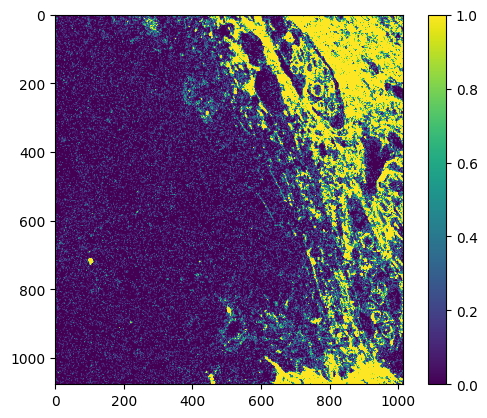

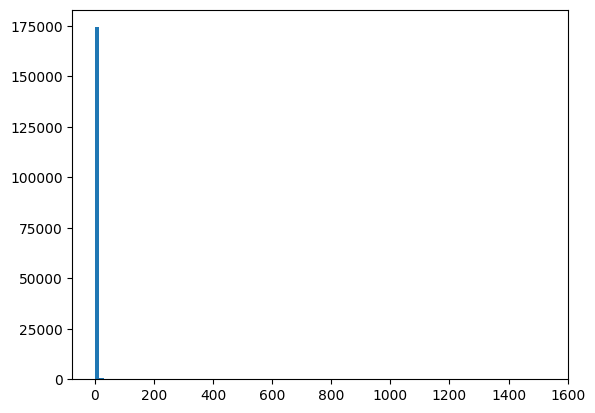

In [79]:
img.shape,len(acquisition.channel_labels)
plt.imshow(np.squeeze(img[np.array(acquisition.channel_labels) == '195Pt']),vmax = 1)
plt.colorbar()
plt.figure()

a = np.reshape(img[np.array(acquisition.channel_labels) == '195Pt'],-1)
_ = plt.hist(a[a>0],100)


(array([1.9523e+04, 1.5790e+03, 7.2000e+01, 4.0000e+00, 2.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00]),
 array([3.50847989e-02, 2.61382580e+00, 5.19256687e+00, 7.77130795e+00,
        1.03500490e+01, 1.29287901e+01, 1.55075312e+01, 1.80862713e+01,
        2.06650124e+01, 2.32437534e+01, 2.58224945e+01, 2.84012356e+01,
        3.09799767e+01, 3.35587196e+01, 3.61374588e+01, 3.87162018e+01,
        4.12949409e+01, 4.38736839e+01, 4.64524231e+01, 4.90311661e+01,
        5.16099052e+01]),
 <BarContainer object of 20 artists>)

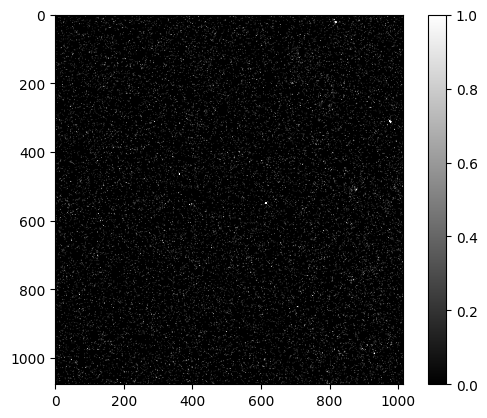

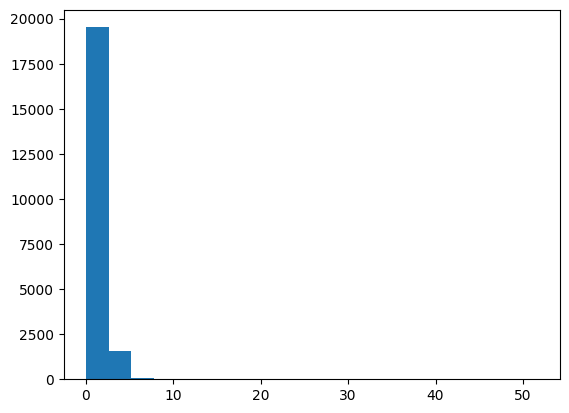

In [78]:
img.shape,len(acquisition.channel_labels)
plt.imshow(np.squeeze(img[np.array(acquisition.channel_labels) == '197Au']),vmax = 1,cmap = 'gray')
plt.colorbar()
plt.figure()
a = np.reshape(img[np.array(acquisition.channel_labels) == '197Au'],-1)
plt.hist(a[a>0],20)

In [65]:
imgs = []
with MCDFile('../IMC_data/Leap001/raw/Leap001.mcd') as f:
    for slide in f.slides:
        for acquisition in slide.acquisitions:
            if int(acquisition.metadata['DataEndOffset'])==0:
                #corrupted acquisition
                continue
            try:
                img2 = f.read_before_ablation_image(acquisition)
                imgs+=[img2]
            except OSError:
                continue # if mcd corrupt, move to next acquisition
            break

In [64]:
img.shape
acquisition.channel_labels

['80ArAr',
 '89Y',
 '90Zr',
 '99Ru',
 '103Rh',
 '106Pd',
 '107Ag',
 '112Cd',
 '114Cd',
 '115In',
 '120Sn',
 '127I',
 '131Xe',
 '138Ba',
 '139La',
 '140Ce',
 '141Pr-CD38',
 '142Nd-EGFR',
 '143Nd-p53',
 '144Nd-CD14',
 '145Nd-Tbet',
 '146Nd-CD16',
 '147Sm-CD163',
 '148Nd-Pan-keratin',
 '149Sm-CD11b',
 '150Nd-PD-L1',
 '151Eu-CD107a',
 '152Sm-CD45',
 '153Eu-CD44',
 '154Sm-CD366',
 '155Gd-FOXP3',
 '156Gd-CD4',
 '157Gd',
 '158Gd-E-Cadherin',
 '159Tb-CD68',
 '160Gd-HLA-DR-DQ-DP',
 '161Dy-CD20',
 '162Dy-CD8a',
 '163Dy-VEGF',
 '164Dy-PD-1',
 '165Ho-Beta-Catenin',
 '166Er-B7-H4',
 '167Er-Granzyme-B',
 '168Er-Ki-67',
 '169Tm-Collage-Type_I',
 '170Er-CD3',
 '171Yb-CD27',
 '172Yb-PD-L2',
 '173Yb-CD45RO',
 '174Yb-Alpha-SMA',
 '175Lu-Vimentin',
 '176Yb-CD31',
 '177Hf',
 '190BCKG',
 '191Ir-DNA1',
 '192Os',
 '193Ir-DNA2',
 '195Pt',
 '197Au',
 '202Hg',
 '207Pb',
 '209Bi']

In [28]:

tifffile.imwrite( 'Leap1_'+acquisition.metadata['ID']+'.tiff',
data=imgs[-1])

#plt.savefig(,dpi = 'figure')

In [13]:
#plt.imshow(imgs[1])
imgs[0].shape

(1058, 1084, 4)

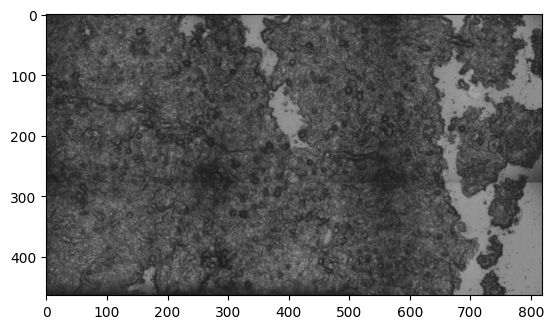

In [89]:
plt.imshow(imgs[2])

In [40]:
base_dir = '../combined_tiff'
file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension

# Create a pattern to search for subdirectories with names starting with 'Leap'
sub_dir_pattern = os.path.join(base_dir, 'Leap*')

# Use glob to find all TIFF files in the subdirectories
tiff_files = glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True)
panel_folders = ['/'.join(el.split('/')[:-1]) for el in tiff_files]# 1 level up tiff files


In [11]:
from pathlib import Path

Init signature: Path(*args, **kwargs)
Docstring:     
PurePath subclass that can make system calls.

Path represents a filesystem path but unlike PurePath, also offers
methods to do system calls on path objects. Depending on your system,
instantiating a Path will return either a PosixPath or a WindowsPath
object. You can also instantiate a PosixPath or WindowsPath directly,
but cannot instantiate a WindowsPath on a POSIX system or vice versa.
File:           ~/anaconda3/lib/python3.9/pathlib.py
Type:           type
Subclasses:     PosixPath, WindowsPath